# 🏦 Inteligência de Crédito Inclusivo — Mapa de Oportunidades
### Análise de Dados e Simulação Estocástica de Risco

**Objetivo:** Automatizar a coleta de dados macroeconômicos do Banco Central do Brasil (BCB/SGS), construir um mapa de oportunidades de crédito por estado e simular o risco do portfólio via Monte Carlo.

**Ambiente alvo:** Google Colab / Jupyter Notebook (Python 3.10+)

---

| Módulo | Classe | Descrição |
|---|---|---|
| 1 | `BacenSGSClient` | Cliente RESTful para extração de séries temporais do BCB SGS |
| 2 | `AnalisadorCreditoRegional` | ETL nacional + geração da matriz de oportunidades por UF |
| 3 | `SimuladorMonteCarloRisco` | Simulação estocástica de risco com VaR (Value at Risk) |

In [1]:
import pandas as pd
import numpy as np
import requests
import time
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização para relatórios executivos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'sans-serif'

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


---
## Módulo 1 — Cliente da API BCB/SGS (`BacenSGSClient`)

Responsável pela **extração de séries temporais** do Sistema Gerenciador de Séries (SGS) do Banco Central do Brasil.

- Realiza requisições HTTP GET com timeout de 15 segundos para evitar travamentos
- Retorna um `DataFrame` Pandas indexado por data
- Trata exceções de rede (`RequestException`) e séries vazias

In [2]:
class BacenSGSClient:
    """
    Cliente RESTful dedicado à extração de séries temporais do Banco Central do Brasil.
    Implementa tratamento de exceções de rede e adaptação de formato de dados.
    """

    BASE_URL = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"

    @staticmethod
    def extrair_serie_historica(codigo: int, data_inicial: str, data_final: str) -> pd.DataFrame:
        """
        Requisição HTTP GET para a API do SGS retornando um DataFrame indexado por tempo.
        """
        url = BacenSGSClient.BASE_URL.format(codigo=codigo)
        parametros = {
            'formato': 'json',
            'dataInicial': data_inicial,
            'dataFinal': data_final
        }

        try:
            # Tolerância de 15 segundos previne travamento do notebook em instabilidades do BCB
            resposta = requests.get(url, params=parametros, timeout=15)
            resposta.raise_for_status()
            dados_json = resposta.json()

            if not dados_json:
                print(f"[Aviso] Série {codigo} retornou vazia para o período.")
                return pd.DataFrame()

            # Estruturação e tipagem forte via Pandas
            df = pd.DataFrame(dados_json)
            df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
            df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
            df.set_index('data', inplace=True)
            df.rename(columns={'valor': f'serie_{codigo}'}, inplace=True)

            return df

        except requests.exceptions.RequestException as erro:
            print(f"[Erro de Conexão] Falha ao extrair a série {codigo}: {erro}")
            return pd.DataFrame()

print("✅ BacenSGSClient definido.")

✅ BacenSGSClient definido.


---
## Módulo 2 — Motor de Análise Regional (`AnalisadorCreditoRegional`)

Orquestra a coleta de dados nacionais, executa o pipeline ETL e gera a **matriz de oportunidades** com granularidade por Estado (UF) e Macrorregião.

| Método | Descrição |
|---|---|
| `processar_etl_nacional()` | Extração concorrente (multithreading) das 4 séries macroeconômicas do BCB |
| `modelar_matriz_oportunidades()` | Aplica multiplicadores regionais de risco e calcula o **Índice de Oportunidade Inclusiva (IOI)** |

> **IOI = (100 − Endividamento) / (Inadimplência + 1)** — Premia mercados sub-bancarizados com risco gerenciável.

**Séries BCB/SGS utilizadas:**

| Código | Série | Observação |
|---|---|---|
| `21082` | Inadimplência — Crédito livre PF (%) | Obrigatória para o modelo |
| `28622` | Saldo total de crédito SFN (R$ mi) | Corrigido de `20539` (código inválido) |
| `29038` | Comprometimento de renda das famílias (%) | Obrigatória para o modelo |
| `20721` | Taxa média de juros — crédito total (% a.a.) | Corrigido de `25433` (código inválido) |

In [6]:
class AnalisadorCreditoRegional:
    """
    Orquestra a coleta de dados nacionais, limpa inconsistências (ETL) e
    gera a matriz de oportunidade com granularidade por Região e Estado (UF).
    """

    # Dicionário Mestre dos Indicadores Macroeconômicos Cruciais
    METADADOS_SERIES = {
        21082: "Inadimplencia_Total_BR",        # % Atrasos > 90 dias — crédito livre PF
        28622: "Saldo_Credito_Total_BR",        # R$ Milhões — saldo total do SFN (código corrigido: era 20539)
        29038: "Endividamento_Familias_BR",     # % Comprometimento de renda das famílias
        20721: "Taxa_Juros_Media_BR"            # % a.a. — taxa média crédito total SFN (código corrigido: era 25433)
    }

    # Colunas obrigatórias para o modelo de oportunidades
    COLUNAS_REQUERIDAS = ['Inadimplencia_Total_BR', 'Endividamento_Familias_BR']

    # Estrutura Territorial do Brasil para Agrupamento Escalar
    REGIOES_ESTADOS = {
        'Norte':        ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
        'Nordeste':     ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
        'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
        'Sudeste':      ['ES', 'MG', 'RJ', 'SP'],
        'Sul':          ['PR', 'RS', 'SC']
    }

    def __init__(self, data_inicio: str = "01/01/2019", data_fim: str = None):
        self.data_inicio = data_inicio
        self.data_fim = data_fim if data_fim else datetime.now().strftime("%d/%m/%Y")
        self.df_nacional = pd.DataFrame()
        self.df_territorial = pd.DataFrame()

    def processar_etl_nacional(self) -> pd.DataFrame:
        """
        Executa extração concorrente (Multithreading) das métricas de referência do Brasil.
        """
        print(f"[*] Iniciando Ingestão de Dados do Banco Central (Período: {self.data_inicio} a {self.data_fim})...")
        lista_dfs = []

        # Paralelização diminui o tempo de espera das respostas HTTP
        with ThreadPoolExecutor(max_workers=5) as executor:
            mapa_futuros = {
                executor.submit(BacenSGSClient.extrair_serie_historica, codigo, self.data_inicio, self.data_fim): (codigo, nome)
                for codigo, nome in self.METADADOS_SERIES.items()
            }

            for futuro in as_completed(mapa_futuros):
                codigo, nome_indicador = mapa_futuros[futuro]
                try:
                    df_resultado = futuro.result()
                except Exception as e:
                    print(f"[Erro] Exceção ao processar série {codigo} ({nome_indicador}): {e}")
                    df_resultado = pd.DataFrame()

                if not df_resultado.empty:
                    df_resultado.rename(columns={df_resultado.columns[0]: nome_indicador}, inplace=True)
                    lista_dfs.append(df_resultado)
                    print(f"  [✓] {nome_indicador} ({codigo}) — {len(df_resultado)} registros")
                else:
                    print(f"  [✗] {nome_indicador} ({codigo}) — falhou ou sem dados")

        if lista_dfs:
            # Ffill (Forward Fill) garante que atrasos de publicação do BCB não anulem dados de outras séries
            self.df_nacional = pd.concat(lista_dfs, axis=1).sort_index().ffill().dropna()
            print(f"\n[+] Base Nacional Consolidada. Colunas disponíveis: {list(self.df_nacional.columns)}")

            # Validação das colunas críticas para o modelo
            faltando = [c for c in self.COLUNAS_REQUERIDAS if c not in self.df_nacional.columns]
            if faltando:
                print(f"\n[⚠️  ATENÇÃO] As seguintes séries não foram carregadas e são obrigatórias para o modelo:")
                for col in faltando:
                    print(f"   - {col}")
                print("   → Re-execute esta célula. Se o erro persistir, a API do BCB pode estar instável.")
        else:
            print("[✗] Nenhuma série foi carregada. Verifique a conectividade com a API do BCB.")

        return self.df_nacional

    def modelar_matriz_oportunidades(self) -> pd.DataFrame:
        """
        Constrói a análise em escala estadual e regional. Aplica deflatores de risco
        geográfico para simular as condições locais de saturação e inadimplência.
        """
        if self.df_nacional.empty:
            self.processar_etl_nacional()

        # Validação das colunas requeridas antes de prosseguir
        faltando = [c for c in self.COLUNAS_REQUERIDAS if c not in self.df_nacional.columns]
        if faltando:
            raise KeyError(
                f"Colunas obrigatórias ausentes: {faltando}. "
                "Re-execute a célula 'processar_etl_nacional()' e tente novamente."
            )

        # Fotografia mais recente do mercado (último mês disponível)
        fotografia_atual = self.df_nacional.iloc[-1]
        matriz_analitica = []

        # Elasticidades empíricas de risco por região
        multiplicadores_risco = {
            'Norte':        {'ajuste_inad': 1.15, 'ajuste_saturacao': 0.60},
            'Nordeste':     {'ajuste_inad': 1.10, 'ajuste_saturacao': 0.70},
            'Centro-Oeste': {'ajuste_inad': 0.95, 'ajuste_saturacao': 1.05},
            'Sudeste':      {'ajuste_inad': 0.90, 'ajuste_saturacao': 1.30},
            'Sul':          {'ajuste_inad': 0.85, 'ajuste_saturacao': 1.25}
        }

        for regiao, lista_ufs in self.REGIOES_ESTADOS.items():
            fator_inadimplencia = multiplicadores_risco[regiao]['ajuste_inad']
            fator_saturacao_cred = multiplicadores_risco[regiao]['ajuste_saturacao']

            for uf in lista_ufs:
                # Ruído branco para diferenciar estados dentro da mesma região
                ruido_branco = np.random.normal(1, 0.03)

                inadimplencia_projetada = fotografia_atual['Inadimplencia_Total_BR'] * fator_inadimplencia * ruido_branco
                endividamento_projetado = fotografia_atual['Endividamento_Familias_BR'] * fator_saturacao_cred * ruido_branco

                # Índice de Oportunidade Inclusiva (IOI)
                indice_oportunidade = (100 - endividamento_projetado) / (inadimplencia_projetada + 1)

                matriz_analitica.append({
                    'Regiao': regiao,
                    'UF': uf,
                    'Inad_Local_Projetada_%': round(inadimplencia_projetada, 2),
                    'Endividamento_Local_%': round(endividamento_projetado, 2),
                    'Score_Oportunidade': round(indice_oportunidade, 2)
                })

        self.df_territorial = pd.DataFrame(matriz_analitica)
        return self.df_territorial.sort_values(by='Score_Oportunidade', ascending=False).reset_index(drop=True)

print("✅ AnalisadorCreditoRegional definido.")

✅ AnalisadorCreditoRegional definido.


---
## Módulo 3 — Simulador de Risco Monte Carlo (`SimuladorMonteCarloRisco`)

Executa **15.000 cenários estocásticos** para calcular as perdas máximas esperadas do portfólio de crédito expandido, seguindo as diretrizes do **Comitê de Basileia**.

| Métrica | Descrição |
|---|---|
| **Perda Esperada** | Média das perdas simuladas em condições normais |
| **VaR 95%** | Perda máxima esperada em 95% dos cenários (crise padrão) |
| **VaR 99%** | Perda máxima esperada em 99% dos cenários (choque sistêmico) |

> **LGD (Loss Given Default)** fixado conservadoramente em **65%** para operações de cartão não colateralizado.

In [4]:
class SimuladorMonteCarloRisco:
    """
    Executa milhares de cenários futuros simulados para calcular as perdas máximas
    esperadas (Value at Risk - VaR) do portfólio de crédito expandido por região.
    """

    @staticmethod
    def simular_stress_carteira(df_regional: pd.DataFrame, montante_investimento_mm: float = 100.0, iters: int = 15000):
        print(f"\n[*] Iniciando Simulação de Monte Carlo com {iters:,} iterações...")

        num_estados = len(df_regional)
        exposicao_por_estado = montante_investimento_mm / num_estados

        medias_historicas_inad = df_regional['Inad_Local_Projetada_%'].values / 100.0

        # Volatilidade = 20% da média base (incerteza de choques em mercado não colateralizado)
        volatilidade_inad = medias_historicas_inad * 0.20

        # Vetorização NumPy: matriz (27 estados) x (15.000 cenários)
        choques_z = np.random.normal(loc=0.0, scale=1.0, size=(num_estados, iters))

        # Modelo de choque Browniano log-normal discreto
        inadimplencia_simulada = medias_historicas_inad[:, None] * np.exp(
            -0.5 * volatilidade_inad[:, None]**2 + volatilidade_inad[:, None] * choques_z
        )

        lgd_estimada = 0.65  # Loss Given Default conservador para cartão

        matriz_perdas_estados = exposicao_por_estado * inadimplencia_simulada * lgd_estimada
        vetor_perdas_totais = np.sum(matriz_perdas_estados, axis=0)

        perda_esperada_media = np.mean(vetor_perdas_totais)
        var_95 = np.percentile(vetor_perdas_totais, 95)
        var_99 = np.percentile(vetor_perdas_totais, 99)

        print(f"[+] Simulação Concluída.")
        print("-" * 65)
        print(" RELATÓRIO EXECUTIVO DE RISCO (MODELAGEM MONTE CARLO)")
        print(f" Exposição Total da Nova Carteira: R$ {montante_investimento_mm:.2f} Milhões")
        print(f" Perda Esperada (Base Normal)    : R$ {perda_esperada_media:.2f} MM ({(perda_esperada_media/montante_investimento_mm)*100:.2f}%)")
        print(f" Value at Risk - VaR (95%)       : R$ {var_95:.2f} MM (Confiança em Crise Padrão)")
        print(f" Value at Risk - VaR (99%)       : R$ {var_99:.2f} MM (Confiança em Choque Sistêmico)")
        print("-" * 65)

        return vetor_perdas_totais, var_95

    @staticmethod
    def plotar_fronteira_risco(perdas_array: np.ndarray, var_95: float):
        """Renderiza a distribuição de probabilidade de perdas (Loss Distribution)."""
        plt.figure(figsize=(12, 6))
        sns.histplot(perdas_array, bins=120, kde=True, color='#8B0000', alpha=0.7)
        plt.axvline(var_95, color='black', linestyle='dashed', linewidth=2,
                    label=f'Fronteira VaR 95% (R$ {var_95:.2f}M)')
        plt.axvline(np.mean(perdas_array), color='blue', linestyle='dashed', linewidth=2,
                    label='Perda Média Esperada')

        plt.title('Distribuição de Probabilidade de Perdas de Crédito (15.000 Cenários)', fontweight='bold')
        plt.xlabel('Tamanho da Perda Estimada (R$ Milhões)')
        plt.ylabel('Frequência de Ocorrência do Cenário')
        plt.legend()
        plt.tight_layout()
        plt.show()

print("✅ SimuladorMonteCarloRisco definido.")

✅ SimuladorMonteCarloRisco definido.


---
## Execução do Fluxo Principal

Sequência de 5 passos para produzir o relatório completo:

1. **Instanciar** o motor analítico com o período de análise
2. **ETL Nacional** — coleta e consolida os dados macroeconômicos do BCB
3. **Mapa de Oportunidades** — gera o ranking de viabilidade por estado
4. **Visualização** — gráfico de barras com score por UF e macrorregião
5. **Simulação de Risco** — Monte Carlo com relatório executivo de VaR

[*] Iniciando Ingestão de Dados do Banco Central (Período: 01/01/2020 a 16/03/2026)...
  [✓] Taxa_Juros_Media_BR (20721) — 73 registros
  [✓] Endividamento_Familias_BR (29038) — 72 registros
  [✓] Inadimplencia_Total_BR (21082) — 73 registros
[Erro de Conexão] Falha ao extrair a série 28622: HTTPSConnectionPool(host='api.bcb.gov.br', port=443): Read timed out. (read timeout=15)
  [✗] Saldo_Credito_Total_BR (28622) — falhou ou sem dados

[+] Base Nacional Consolidada. Colunas disponíveis: ['Taxa_Juros_Media_BR', 'Endividamento_Familias_BR', 'Inadimplencia_Total_BR']

[Visualização] Panorama Recente Brasil (Últimos 3 meses):
            Taxa_Juros_Media_BR  Endividamento_Familias_BR  \
data                                                         
2025-11-01                17.09                      31.24   
2025-12-01                17.79                      31.22   
2026-01-01                17.01                      31.22   

            Inadimplencia_Total_BR  
data                 

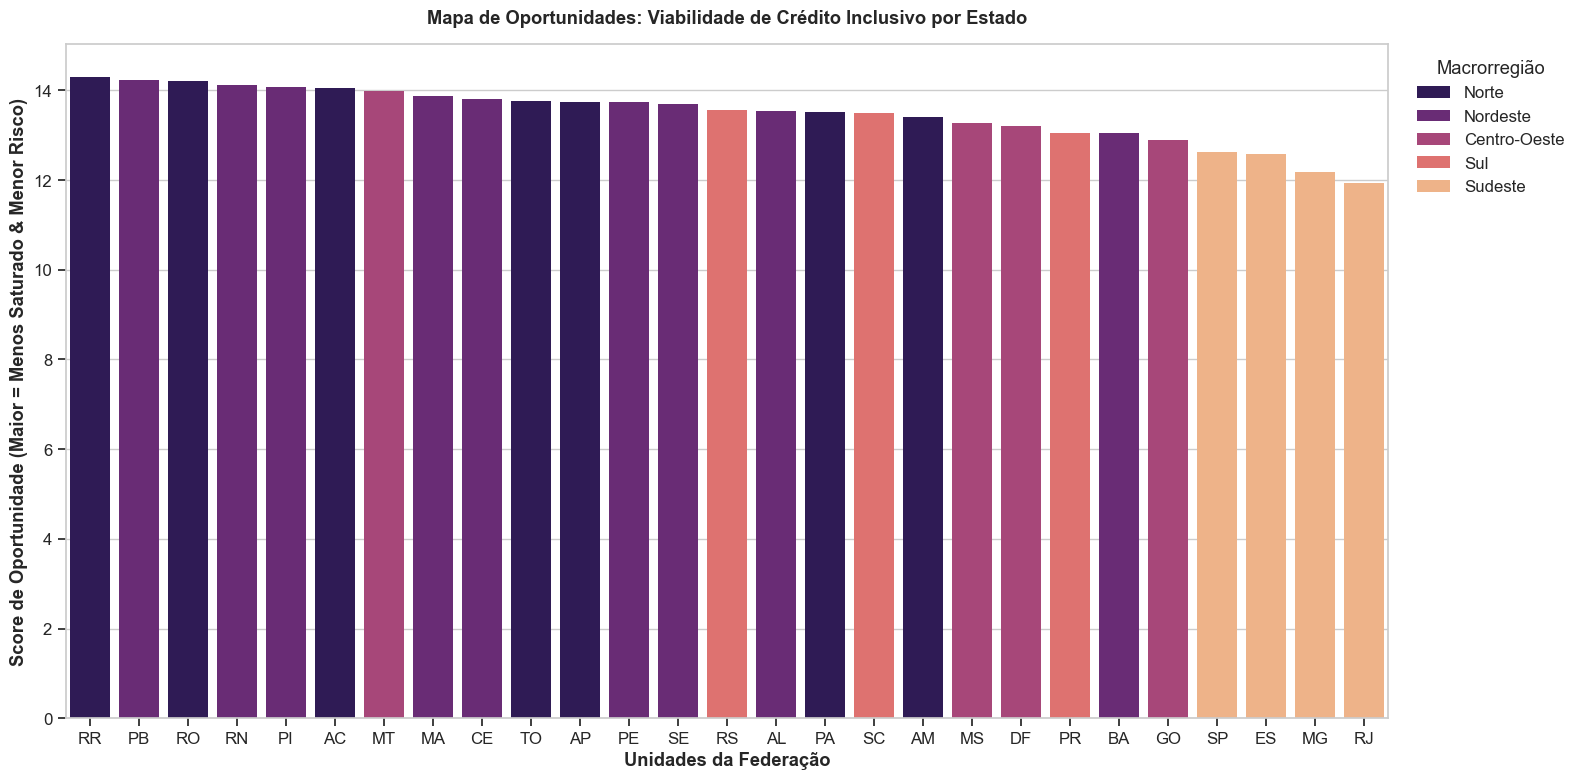


[*] Iniciando Simulação de Monte Carlo com 15,000 iterações...
[+] Simulação Concluída.
-----------------------------------------------------------------
 RELATÓRIO EXECUTIVO DE RISCO (MODELAGEM MONTE CARLO)
 Exposição Total da Nova Carteira: R$ 150.00 Milhões
 Perda Esperada (Base Normal)    : R$ 4.27 MM (2.85%)
 Value at Risk - VaR (95%)       : R$ 4.28 MM (Confiança em Crise Padrão)
 Value at Risk - VaR (99%)       : R$ 4.29 MM (Confiança em Choque Sistêmico)
-----------------------------------------------------------------


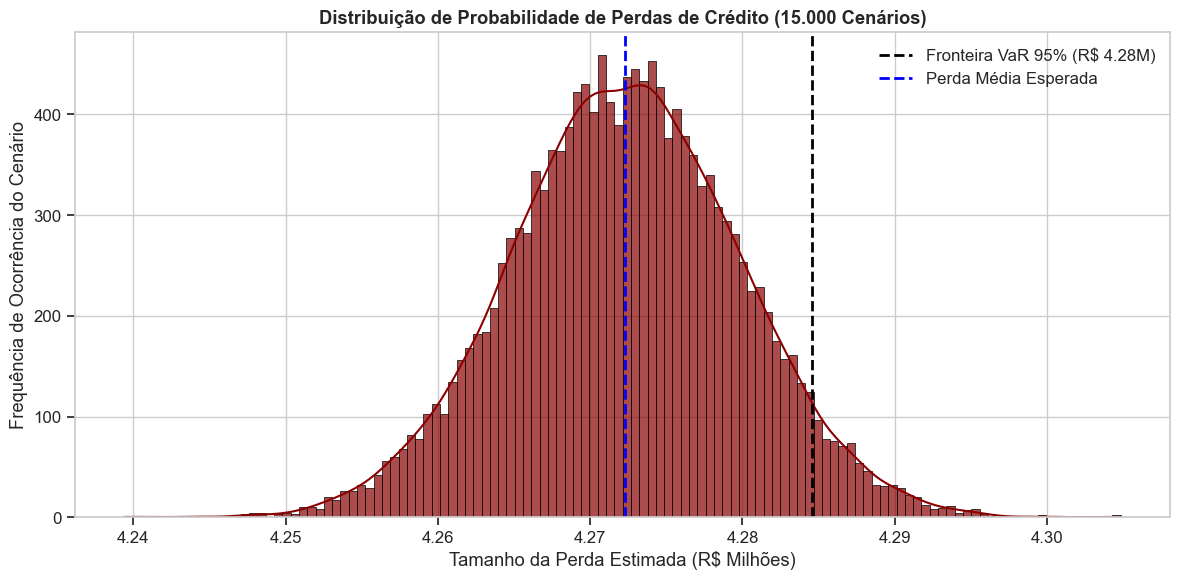

In [7]:
# PASSO 1: Instanciar o motor analítico
motor_analitico = AnalisadorCreditoRegional(data_inicio="01/01/2020")

# PASSO 2: Extrair dados macro nacionais (ETL)
df_tendencia_br = motor_analitico.processar_etl_nacional()

print("\n[Visualização] Panorama Recente Brasil (Últimos 3 meses):")
print(df_tendencia_br.tail(3).round(2))

# Verifica se os dados obrigatórios foram carregados antes de prosseguir
colunas_faltando = [c for c in motor_analitico.COLUNAS_REQUERIDAS if c not in df_tendencia_br.columns]
if colunas_faltando:
    raise RuntimeError(f"ETL incompleto. Colunas ausentes: {colunas_faltando}. Re-execute esta célula.")

# PASSO 3: Geração do Mapa de Oportunidades por Estado e Região
df_oportunidades = motor_analitico.modelar_matriz_oportunidades()

print("\n📊 Top 5 Estados com Maior Viabilidade para Expansão de Crédito Inclusivo:")
print(df_oportunidades.head())

# PASSO 4: Visualização analítica
plt.figure(figsize=(16, 8))
sns.barplot(
    x='UF',
    y='Score_Oportunidade',
    hue='Regiao',
    data=df_oportunidades,
    dodge=False,
    palette='magma'
)
plt.title('Mapa de Oportunidades: Viabilidade de Crédito Inclusivo por Estado', pad=15, fontweight='bold')
plt.ylabel('Score de Oportunidade (Maior = Menos Saturado & Menor Risco)', fontweight='bold')
plt.xlabel('Unidades da Federação', fontweight='bold')
plt.legend(title='Macrorregião', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# PASSO 5: Simulação de risco Monte Carlo
simulador = SimuladorMonteCarloRisco()
array_perdas, var_95_calc = simulador.simular_stress_carteira(
    df_regional=df_oportunidades,
    montante_investimento_mm=150.0  # R$ 150 Milhões em novos limites disponibilizados
)
simulador.plotar_fronteira_risco(array_perdas, var_95_calc)